在 d2l 环境中 (Keras 3 + PyTorch)：
你只需要在脚本最顶部强制指定后端，并统一数据格式。
import os
os.environ["KERAS_BACKEND"] = "torch"  # 指定后端

import keras
# 关键：统一数据格式，这样你就不需要为了 PyTorch 去手动 reshape 成 (1, 8, 8)
keras.config.set_image_data_format("channels_last") 

# 后面的代码（Input, Conv2D, Dense）与你之前的完全一致

在 tf_env 环境中 (Keras 2 + TF)：
Keras 2 不需要指定后端（因为它默认就是 TF），但你需要处理 TF 抢占显存的问题。
import tensorflow as tf
# 显存按需申请，防止 RTX 2060 满载卡顿
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

from tensorflow import keras  # 注意：在老环境中，通常从 tensorflow 导入 keras

1. 无 Keras：原生 TensorFlow 调用 GPU
特点：启动即占用。 TensorFlow（特别是 2.x 版本）非常“霸道”。只要你安装了 tensorflow-gpu，它在启动时就会自动扫描 CUDA 并占满几乎所有显存。
2. 无 Keras：原生 PyTorch 调用 GPU
特点：显式搬运，手动挡控制。 PyTorch 默认所有数据都在 CPU 上，你必须通过代码把模型和每一批数据“搬”进显存。
import torch

    # 1. 手动定义设备
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 2. 显式搬运模型
    model = MyModel().to(device)

    # 3. 循环中显式搬运每一批数据
    for data, target in dataloader:
        data, target = data.to(device), target.to(device) # 这一步漏了会报错
        output = model(data)
3. 有 Keras (Keras 3)：跨后端统一调用
特点：环境感知，全自动适配。 无论你在底层设置后端为 torch 还是 tensorflow，Keras 3 都会模拟 TensorFlow 的“全自动”体验。
    import os
    os.environ["KERAS_BACKEND"] = "torch" # 或者 "tensorflow"

    import keras

    # Keras 3 的黑科技：
    # 虽然底层是 PyTorch，但你不需要写 .to(device)
    # 只要你调用 model.fit(X_np, y_np)，Keras 会自动检测 GPU 
    # 并帮你完成从 Numpy 到 GPU Tensor 的搬运工作。
    model = keras.Sequential([...])
    model.compile(optimizer="adam", loss="mse")
    model.fit(X_train, y_train) # 自动利用 GPU

具体来说，Keras 帮你隐藏了以下四大类“繁琐操作”：

1. 隐藏了“硬件搬运” (Device Placement)
原生操作： 在 PyTorch 中，你要时刻盯着显存，写 model.to(device)；在 TensorFlow 原生中，你要管理 with tf.device()。

Keras 隐藏了什么： 它在后台静默运行一个“资源调度员”。当你点击训练时，它会自动检测你的 RTX 2060，发现它比 CPU 快，就自动把数据和模型“瞬移”到显存里。你甚至不需要知道显存地址在哪。

2. 隐藏了“张量转换” (Tensor Conversion)
原生操作： 你必须反复确认数据是不是 torch.Tensor 或 tf.Tensor，精度是 float32 还是 float64。

Keras 隐藏了什么： 它在 model.fit 的入口处放了一个“通用翻译官”。无论你喂进去的是 NumPy、List 还是 Pandas，它都会在进入计算核心前，自动把它们格式化成后端（Torch 或 TF）最喜欢的张量样式。

3. 隐藏了“梯度计算” (Auto-differentiation)
原生操作： 你需要手动写 loss.backward() (Torch) 或者 tape.gradient() (TF)，还要记得手动清理梯度 optimizer.zero_grad()。

Keras 隐藏了什么： 它把整个数学推导过程封装成了 model.compile()。你只需要告诉它你要用 Adam 优化器，剩下的求导、权重更新等复杂的微积分运算，全部被隐藏在了 model.fit 内部。

4. 隐藏了“后端差异” (Backend Independence)
原生操作： 写 TF 代码的人看不懂 Torch 代码，反之亦然。

Keras 隐藏了什么： 尤其是 Keras 3，它彻底隐藏了底层框架的身份。你写的 layers.Conv2D 是一句“通用指令”，至于底层是用 PyTorch 的卷积核还是 TensorFlow 的卷积核，用户完全不需要关心。

Handwritten Digits Recognition CNN Model

1. Loading and preprocessing data...
Original data shape: (1797, 64)
Label shape: (1797,)
Number of classes: 10
Training set: (1293, 8, 8, 1)
Validation set: (144, 8, 8, 1)
Test set: (360, 8, 8, 1)

2. Visualizing data...


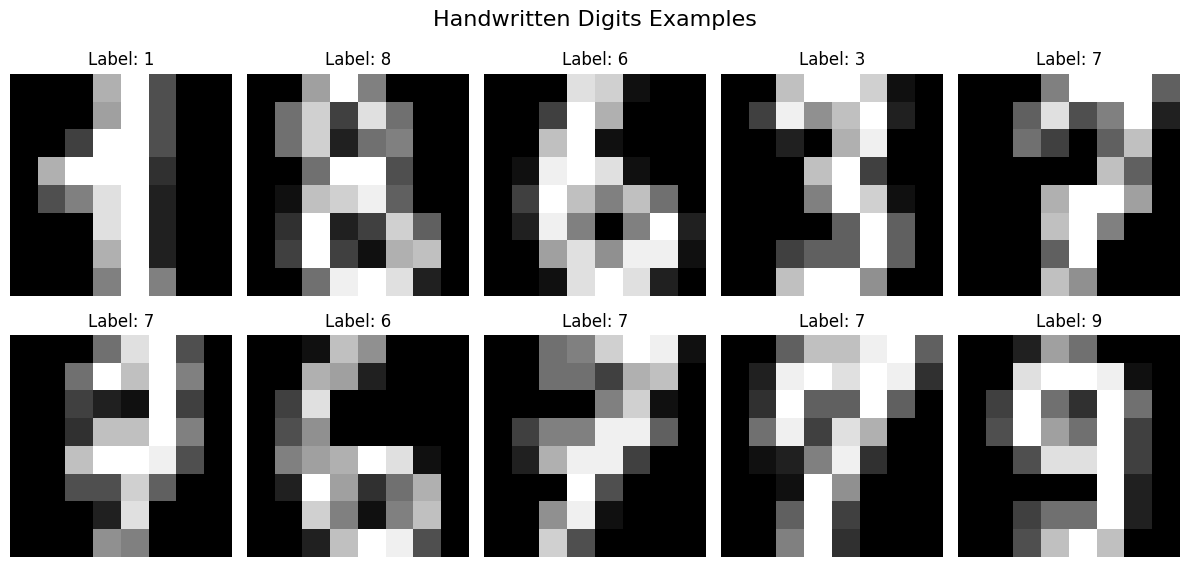

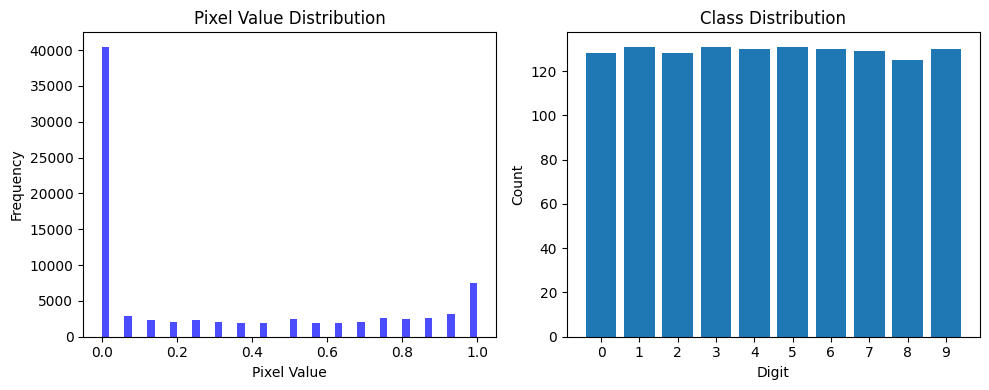


3. Building CNN model...

4. Compiling model...
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (Conv2D)              (None, 8, 8, 32)          320       
                                                                 
 bn1 (BatchNormalization)    (None, 8, 8, 32)          128       
                                                                 
 pool1 (MaxPooling2D)        (None, 4, 4, 32)          0         
                                                                 
 dropout1 (Dropout)          (None, 4, 4, 32)          0         
                                                                 
 conv2 (Conv2D)              (None, 4, 4, 64)          18496     
                                                                 
 bn2 (BatchNormalization)    (None, 4, 4, 64)          256       
                                                                 
 pool2 

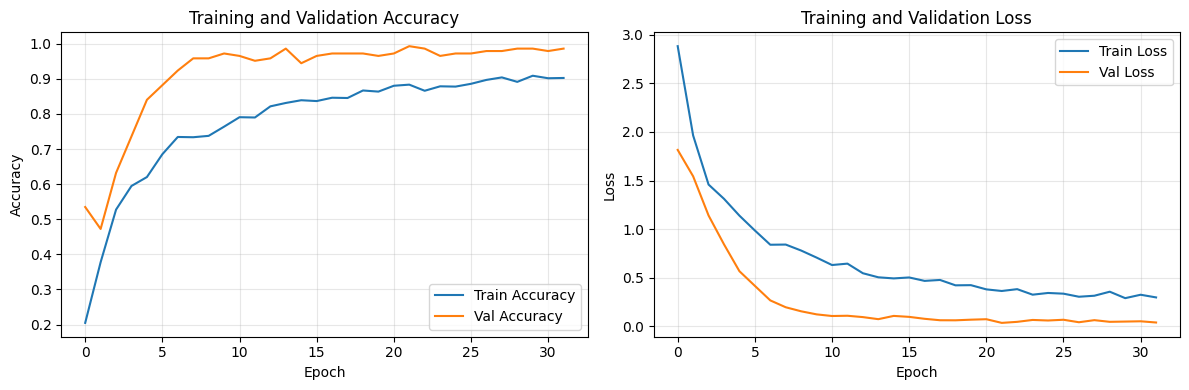


7. Evaluating model...

Evaluating model on test set...
Test Loss: 0.0639
Test Accuracy: 0.9778
Test Top-3 Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        36
           1     1.0000    0.9444    0.9714        36
           2     1.0000    1.0000    1.0000        35
           3     0.9474    0.9730    0.9600        37
           4     1.0000    1.0000    1.0000        36
           5     0.9737    1.0000    0.9867        37
           6     0.9714    0.9444    0.9577        36
           7     0.9730    1.0000    0.9863        36
           8     0.9459    1.0000    0.9722        35
           9     0.9706    0.9167    0.9429        36

    accuracy                         0.9778       360
   macro avg     0.9782    0.9779    0.9777       360
weighted avg     0.9781    0.9778    0.9777       360



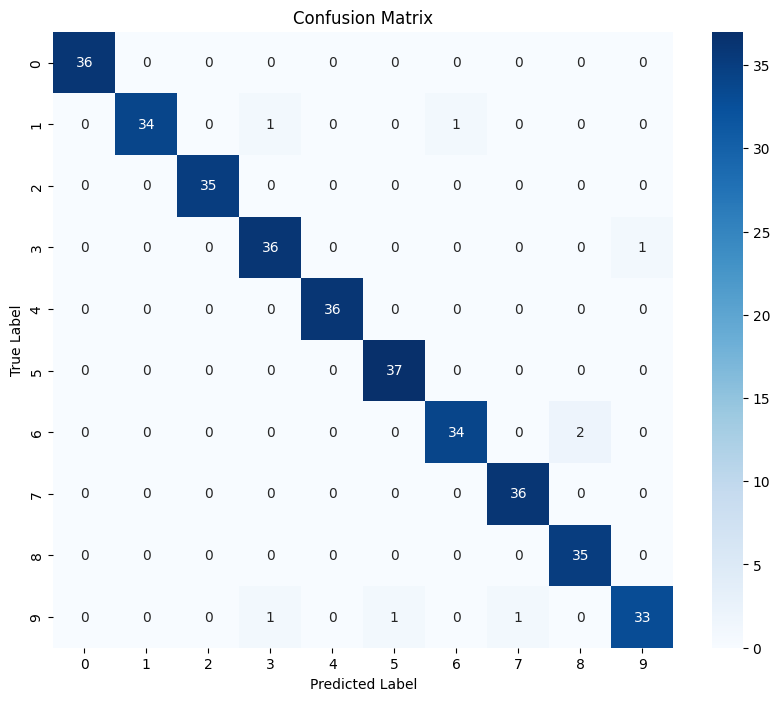


8. Visualizing predictions...
Correct predictions: 352/360
Incorrect predictions: 8/360


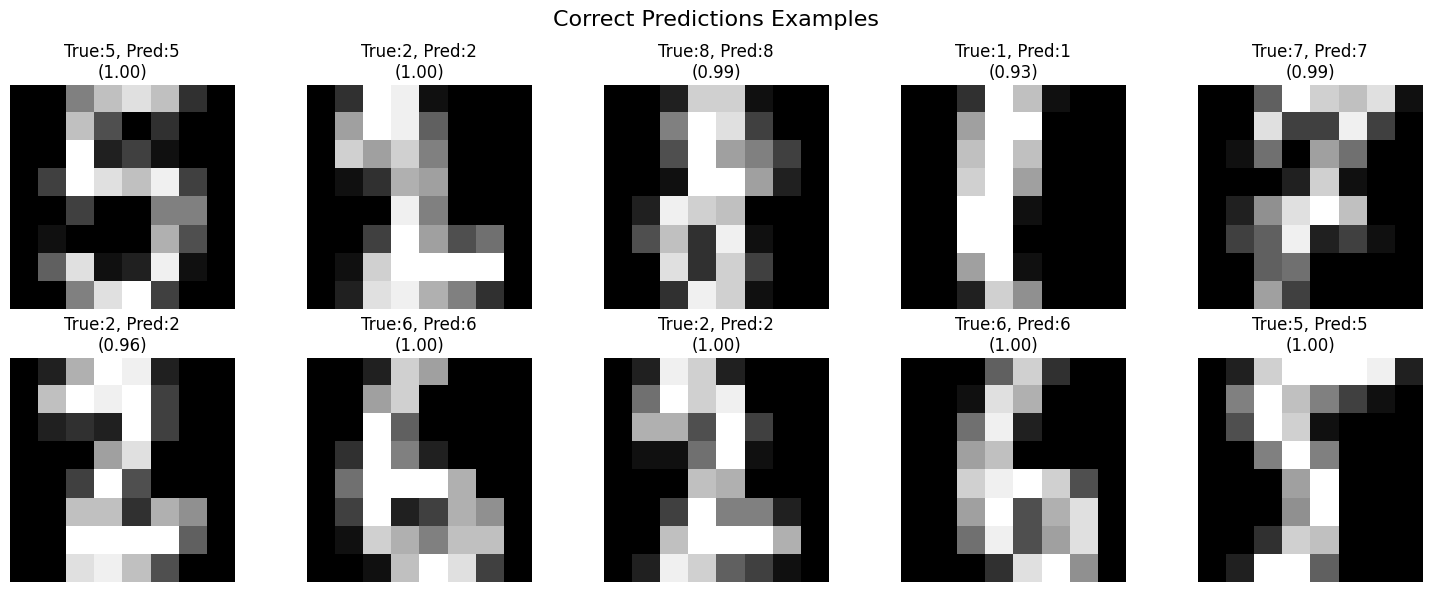

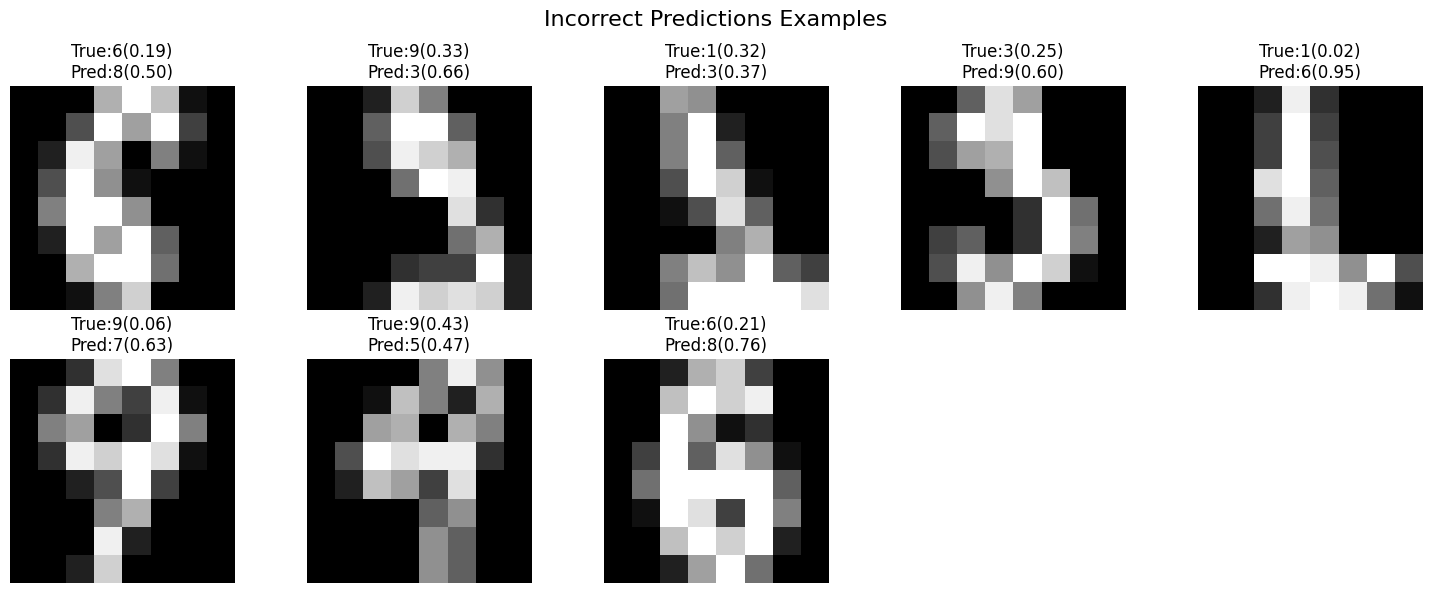


Most common error types:
  6 → 8: 2 times
  9 → 3: 1 times
  1 → 3: 1 times
  3 → 9: 1 times
  1 → 6: 1 times

9. Visualizing feature maps...
Visualizing feature maps...


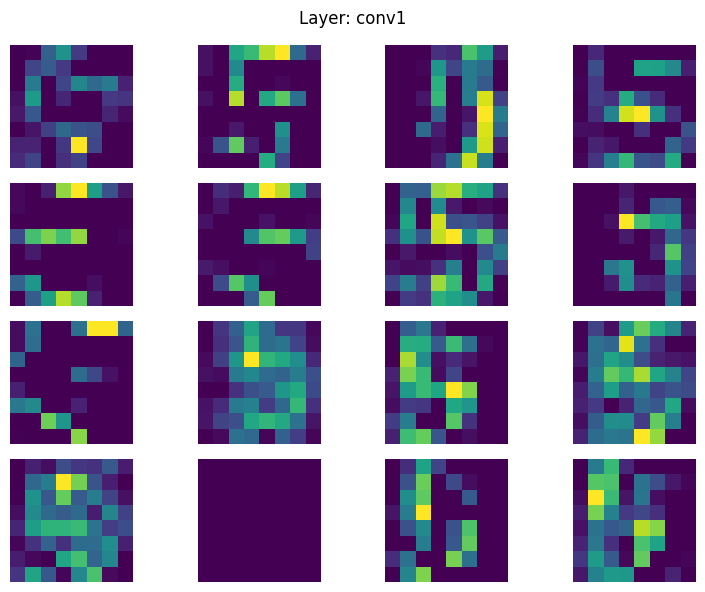

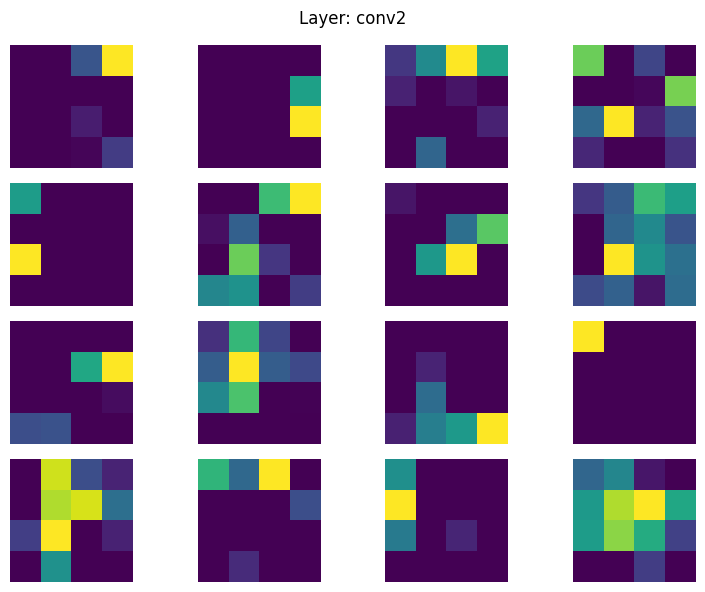

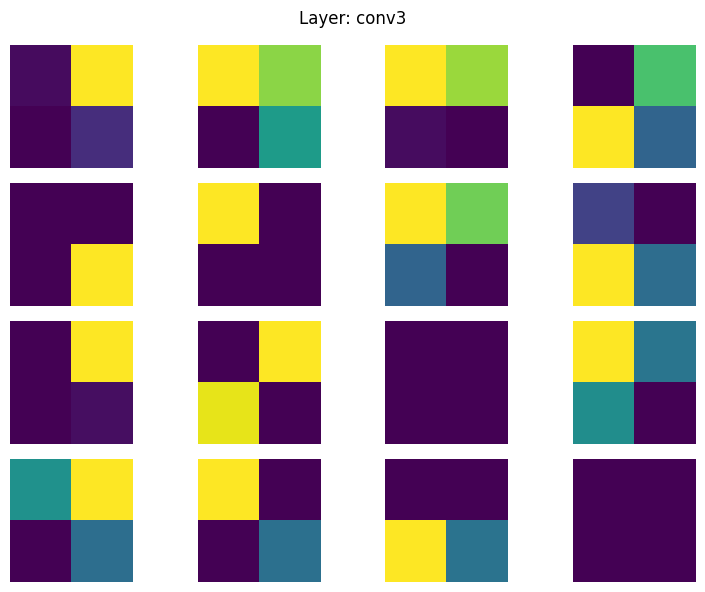


10. Saving model...
Model saved as 'handwriting_digits_cnn_fixed.keras'

11. Testing saved model...
Loaded model test accuracy: 0.9778

Program completed successfully!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 设置随机种子确保可重复性
np.random.seed(42)
tf.random.set_seed(42)

# ==================== 1. 数据加载和预处理 ====================
def load_and_preprocess_digits():
    """加载并预处理digits数据集"""
    #scikit-learn datasets：load_digits() 返回的 data 和 target 属性已经是NumPy数组
    # 加载数据
    digits = datasets.load_digits()
    X = digits.data.astype('float32')
    y = digits.target
    
    # 数据形状信息
    print(f"Original data shape: {X.shape}")
    print(f"Label shape: {y.shape}")
    print(f"Number of classes: {len(np.unique(y))}")
    
    # 重塑为图像格式 (样本数, 高度, 宽度, 通道数)
    X = X.reshape(-1, 8, 8, 1)
    original_images = digits.images.reshape(-1, 8, 8, 1)
    # 标准化像素值到 [0, 1]
    X = X / 16.0  # digits数据集像素范围是0-15
    
    # 分割数据集
    X_train, X_test, y_train, y_test, images_train, images_test = train_test_split(
        X, y, original_images, test_size=0.2, random_state=42, stratify=y
    )
    
    # 进一步分割出验证集
    X_train, X_val, y_train, y_val, images_train, images_val = train_test_split(
        X_train, y_train, images_train, test_size=0.1, random_state=42, stratify=y_train
    )
    
    print(f"Training set: {X_train.shape}")
    print(f"Validation set: {X_val.shape}")
    print(f"Test set: {X_test.shape}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test, images_train, images_val, images_test

# ==================== 2. 可视化数据 ====================
def visualize_data(X, y, images, num_samples=10):
    """可视化数据集样本"""
    plt.figure(figsize=(12, 6))
    for i in range(num_samples):
        plt.subplot(2, 5, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"Label: {y[i]}")
        plt.axis('off')
    plt.suptitle('Handwritten Digits Examples', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # 显示像素值分布
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.hist(X.flatten(), bins=50, alpha=0.7, color='blue')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.title('Pixel Value Distribution')
    
    plt.subplot(1, 2, 2)
    plt.bar(range(10), np.bincount(y.astype(int), minlength=10))
    plt.xlabel('Digit')
    plt.ylabel('Count')
    plt.title('Class Distribution')
    plt.xticks(range(10))
    plt.tight_layout()
    plt.show()

# ==================== 3. 构建CNN模型（修复input_shape警告） ====================
def build_cnn_model(input_shape=(8, 8, 1), num_classes=10):
    """构建CNN模型"""
    model = keras.Sequential([
        # 使用Input层而不是在Conv2D中指定input_shape
        keras.layers.Input(shape=input_shape),
        
        # 第一个卷积块
        keras.layers.Conv2D(32, (3, 3), padding='same', 
                           activation='relu',
                           kernel_initializer='he_normal',
                           name='conv1'),
        keras.layers.BatchNormalization(name='bn1'),
        keras.layers.MaxPooling2D((2, 2), name='pool1'),
        keras.layers.Dropout(0.25, name='dropout1'),
        
        # 第二个卷积块
        keras.layers.Conv2D(64, (3, 3), padding='same',
                           activation='relu',
                           kernel_initializer='he_normal',
                           name='conv2'),
        keras.layers.BatchNormalization(name='bn2'),
        keras.layers.MaxPooling2D((2, 2), name='pool2'),
        keras.layers.Dropout(0.25, name='dropout2'),
        
        # 第三个卷积块
        keras.layers.Conv2D(128, (2, 2), padding='same',
                           activation='relu',
                           kernel_initializer='he_normal',
                           name='conv3'),
        keras.layers.BatchNormalization(name='bn3'),
        keras.layers.Dropout(0.25, name='dropout3'),
        
        # 展平层
        keras.layers.Flatten(name='flatten'),
        
        # 全连接层
        keras.layers.Dense(128, activation='relu',
                          kernel_initializer='he_normal',
                          name='fc1'),
        keras.layers.BatchNormalization(name='bn4'),
        keras.layers.Dropout(0.5, name='dropout4'),
        
        # 输出层
        keras.layers.Dense(num_classes, activation='softmax',
                          name='output')
    ])
    
    return model

# ==================== 4. 编译模型 ====================
def compile_model(model, learning_rate=0.001):
    """编译模型"""
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',  # 对于整数标签
        metrics=[
            'accuracy',
            keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3_accuracy')
        ]
    )
    
    # 显示模型架构
    model.summary()
    
    return model

# ==================== 5. 数据增强（修复steps_per_epoch问题） ====================
def create_image_data_generator():
    """创建图像数据生成器"""
    datagen = keras.preprocessing.image.ImageDataGenerator(
        #参数定义的是范围（Range），而不是一个死数值
        rotation_range=10,
        zoom_range=0.1,
        width_shift_range=0.1,
        height_shift_range=0.1,
        fill_mode='nearest'
    )
    return datagen

# ==================== 6. 训练模型（修复数据增强问题） ====================
def train_model(model, X_train, y_train, X_val, y_val, 
                use_augmentation=True, epochs=50, batch_size=32):
    """训练模型"""
    # 学习率调度器
    lr_scheduler = keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=0
    )
    
    # 早停
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
    
    # 模型检查点
    checkpoint = keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='max',
        verbose=0
    )
    
    # 训练历史记录器
    class TrainingHistory(keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            if (epoch + 1) % 1 == 0:
                print(f"Epoch {epoch+1}: "
                   f"train_loss={logs['loss']:.4f}, "
                   f"train_accuracy={logs['accuracy']:.4f}, "
                   f"train_top3_accuracy={logs['top3_accuracy']:.4f} | "
                   f"val_loss={logs['val_loss']:.4f}, "
                   f"val_accuracy={logs['val_accuracy']:.4f}, "
                   f"val_top3_accuracy={logs['val_top3_accuracy']:.4f}")
    
    print("\n开始训练模型...")
    
    if use_augmentation:
        print("使用数据增强...")
        # 创建数据生成器
        datagen = create_image_data_generator()
        datagen.fit(X_train)
        
        # 计算正确的steps_per_epoch
        steps_per_epoch = max(1, len(X_train) // batch_size)
        
        # 使用数据增强进行训练
        history = model.fit(
            datagen.flow(X_train, y_train, batch_size=batch_size),
            steps_per_epoch=steps_per_epoch,
            validation_data=(X_val, y_val),
            epochs=epochs,
            callbacks=[lr_scheduler, early_stopping, checkpoint, TrainingHistory()],
            verbose=0
        )
    else:
        print("不使用数据增强...")
        # 不使用数据增强
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[lr_scheduler, early_stopping, checkpoint, TrainingHistory()],
            verbose=0
        )
    
    return history, model

# ==================== 7. 可视化训练过程 ====================
def plot_training_history(history):
    """可视化训练历史"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # 准确率
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Training and Validation Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 损失
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Training and Validation Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ==================== 8. 模型评估 ====================
def evaluate_model(model, X_test, y_test):
    """评估模型性能"""
    print("\nEvaluating model on test set...")
    test_results = model.evaluate(X_test, y_test, verbose=0)
    
    print(f"Test Loss: {test_results[0]:.4f}")
    print(f"Test Accuracy: {test_results[1]:.4f}")
    if len(test_results) > 2:
        print(f"Test Top-3 Accuracy: {test_results[2]:.4f}")
    
    # 预测
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    
    # 分类报告
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    
    # 混淆矩阵
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=range(10), yticklabels=range(10))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()
    
    return y_pred, y_pred_prob

# ==================== 9. 可视化预测结果 ====================
def visualize_predictions(X_test, y_test, y_pred, y_pred_prob, 
                         original_images, num_samples=15):
    """可视化预测结果"""
    # 找出一些正确和错误的预测
    correct_indices = np.where(y_pred == y_test)[0]
    incorrect_indices = np.where(y_pred != y_test)[0]
    
    print(f"Correct predictions: {len(correct_indices)}/{len(y_test)}")
    print(f"Incorrect predictions: {len(incorrect_indices)}/{len(y_test)}")
    
    # 显示一些正确预测
    if len(correct_indices) > 0:
        plt.figure(figsize=(15, 6))
        plt.suptitle('Correct Predictions Examples', fontsize=16)
        for i, idx in enumerate(correct_indices[:min(10, len(correct_indices))]):
            plt.subplot(2, 5, i+1)
            plt.imshow(original_images[idx], cmap='gray')
            pred_prob = y_pred_prob[idx][y_pred[idx]]
            plt.title(f"True:{y_test[idx]}, Pred:{y_pred[idx]}\n({pred_prob:.2f})")
            plt.axis('off')
        plt.tight_layout()
        plt.show()
    
    # 显示一些错误预测
    if len(incorrect_indices) > 0:
        plt.figure(figsize=(15, 6))
        plt.suptitle('Incorrect Predictions Examples', fontsize=16)
        for i, idx in enumerate(incorrect_indices[:min(10, len(incorrect_indices))]):
            plt.subplot(2, 5, i+1)
            plt.imshow(original_images[idx], cmap='gray')
            true_label = y_test[idx]
            pred_label = y_pred[idx]
            true_prob = y_pred_prob[idx][true_label]
            pred_prob = y_pred_prob[idx][pred_label]
            plt.title(f"True:{true_label}({true_prob:.2f})\nPred:{pred_label}({pred_prob:.2f})")
            plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        # 分析最常见的错误类型
        error_pairs = []
        for idx in incorrect_indices:
            error_pairs.append((y_test[idx], y_pred[idx]))
        
        from collections import Counter
        common_errors = Counter(error_pairs).most_common(5)
        print("\nMost common error types:")
        for (true, pred), count in common_errors:
            print(f"  {true} → {pred}: {count} times")

# ==================== 10. 修复的特征图可视化 ====================
def visualize_feature_maps(model, X_sample):
    """可视化特征图的修复版本"""
    print("Visualizing feature maps...")
    
    # 1. 确保输入数据形状为 (1, 8, 8, 1)
    if X_sample.ndim == 3:
        img_tensor = np.expand_dims(X_sample, axis=0)
    else:
        img_tensor = X_sample.copy()

    # 2. 获取你想要可视化的层
    # 注意：在 Sequential 模型中，我们可以通过 model.layers[0] 获取第一层
    target_layers = ['conv1', 'conv2', 'conv3']
    outputs = [model.get_layer(name).output for name in target_layers]
    
    # 3. 关键点：使用 model.input 之前，确保模型已通过数据调用过
    # 或者直接使用底层 layer 的 input
    try:
        feature_extractor = keras.Model(inputs=model.input, outputs=outputs)
    except AttributeError:
        # 如果 model.input 报错，尝试从第一层获取输入
        feature_extractor = keras.Model(inputs=model.layers[0].input, outputs=outputs)
    
    # 4. 获取特征图
    layer_outputs = feature_extractor.predict(img_tensor, verbose=0)
    
    # 5. 绘图逻辑 (保持你原来的即可)
    for name, features in zip(target_layers, layer_outputs):
        n_features = min(16, features.shape[-1])
        n_cols = 4
        n_rows = (n_features + n_cols - 1) // n_cols
        
        plt.figure(figsize=(n_cols * 2, n_rows * 1.5))
        plt.suptitle(f'Layer: {name}', fontsize=12)
        
        for i in range(n_features):
            plt.subplot(n_rows, n_cols, i+1)
            f_map = features[0, :, :, i]
            # 归一化以增强显示效果
            f_min, f_max = f_map.min(), f_map.max()
            if f_max > f_min:
                f_map = (f_map - f_min) / (f_max - f_min)
            plt.imshow(f_map, cmap='viridis')
            plt.axis('off')
        plt.tight_layout()
        plt.show()
# ==================== 11. 主函数 ====================
def main():
    """主函数"""
    print("=" * 60)
    print("Handwritten Digits Recognition CNN Model")
    print("=" * 60)
    
    # 1. 加载和预处理数据
    print("\n1. Loading and preprocessing data...")
    X_train, X_val, X_test, y_train, y_val, y_test, images_train, images_val, images_test = load_and_preprocess_digits()
    
    # 2. 可视化数据
    print("\n2. Visualizing data...")
    visualize_data(X_train, y_train, images_train)
    
    # 3. 构建模型
    print("\n3. Building CNN model...")
    model = build_cnn_model(input_shape=(8, 8, 1), num_classes=10)
    
    # 4. 编译模型
    print("\n4. Compiling model...")
    model = compile_model(model, learning_rate=0.001)
    
    # 5. 训练模型
    print("\n5. Training model...")
    history, trained_model = train_model(
        model, X_train, y_train, X_val, y_val,
        use_augmentation=True,  # 设为False可以关闭数据增强
        epochs=50,
        batch_size=32
    )
    
    # 6. 可视化训练过程
    print("\n6. Visualizing training history...")
    plot_training_history(history)
    
    # 7. 评估模型
    print("\n7. Evaluating model...")
    y_pred, y_pred_prob = evaluate_model(trained_model, X_test, y_test)
    
    # 8. 可视化预测结果
    print("\n8. Visualizing predictions...")
    test_original_images = images_test
    visualize_predictions(X_test, y_test, y_pred, y_pred_prob, 
                         test_original_images)
    
    # 9. 可视化特征图
    print("\n9. Visualizing feature maps...")
    sample_idx = 0
    # 确保函数名一致
    visualize_feature_maps(trained_model, X_test[sample_idx])
    
    # 10. 保存模型
    print("\n10. Saving model...")
    trained_model.save('handwriting_digits_cnn_fixed.keras')
    print("Model saved as 'handwriting_digits_cnn_fixed.keras'")
    
    # 11. 测试保存的模型
    print("\n11. Testing saved model...")
    loaded_model = keras.models.load_model('handwriting_digits_cnn_fixed.keras')
    loaded_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    test_loss, test_acc = loaded_model.evaluate(X_test, y_test, verbose=0)
    print(f"Loaded model test accuracy: {test_acc:.4f}")
    
    print("\n" + "=" * 60)
    print("Program completed successfully!")
    print("=" * 60)
    
    return trained_model, history, (X_test, y_test, y_pred, y_pred_prob)

# ==================== 12. 运行程序 ====================
if __name__ == "__main__":
    model, history, results = main()

In [1]:
import keras
import tensorflow as tf

print(f"Keras 使用的后端: {keras.backend.backend()}")
# 检查物理 GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ 成功找到 GPU: {gpus}")
else:
    print("❌ 未找到 GPU，请检查显卡驱动")

Keras 使用的后端: tensorflow
✅ 成功找到 GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
